#  Notebook 01 — Exploratory Data Analysis (EDA)
### Amazon Fine Food Reviews · IASD Big Data Project 2025-2026

---

##  Objectif

Comprendre le dataset **avant** tout Machine Learning.
Chaque décision prise dans Notebook 02 et 03 est **justifiée par une observation ici**.

| Section | Ce qu'on découvre |
|---------|------------------|
| **1** | Chargement, schéma, taille |
| **2** | Valeurs nulles & doublons |
| **3** | Distribution des scores & sentiments |
| **4** | Analyse longueur des textes |
| **5** | Fréquence des mots par classe (après stopwords) |
| **6** | Word Clouds nettoyés |
| **7** | Décisions clés pour la modélisation |

> **Architecture role:** Ce notebook produit uniquement des **insights documentés**.


In [1]:

# ============================================================
# SECTION 1 — Setup & Chargement du Dataset
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, when, length, lower, regexp_replace,
    concat_ws, coalesce, lit, count, avg
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

spark = SparkSession.builder \
    .appName("01_EDA_AmazonReviews") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

LABEL_COLORS = {"Negative": "#e74c3c", "Neutral": "#f39c12", "Positive": "#2ecc71"}
LABEL_ORDER  = ["Negative", "Neutral", "Positive"]

# --- Chargement ---
# multiLine=True : gère les reviews avec des retours à la ligne internes
# quote/escape   : gère les virgules et guillemets dans les reviews
df = spark.read.csv(
    "Reviews.csv",
    header=True, inferSchema=True,
    multiLine=True, quote='"', escape='"'
)

# Renommer Summary pour éviter les conflits avec les stages ML PySpark
df = df.withColumnRenamed("Summary", "Review_Summary")
df = df.withColumn("Score", col("Score").cast("int"))

total = df.count()
print(f"Dataset chargé : {total:,} reviews")
print(f"Colonnes : {df.columns}")
print(f"Mémoire estimée : {df.rdd.map(lambda r: len(str(r))).sum() / 1e6:.0f} MB")
df.printSchema()


Dataset chargé : 568,454 reviews
Colonnes : ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Review_Summary', 'Text']
Mémoire estimée : 373 MB
root
 |-- Id: integer (nullable = true)
 |-- ProductId: string (nullable = true)
 |-- UserId: string (nullable = true)
 |-- ProfileName: string (nullable = true)
 |-- HelpfulnessNumerator: integer (nullable = true)
 |-- HelpfulnessDenominator: integer (nullable = true)
 |-- Score: integer (nullable = true)
 |-- Time: integer (nullable = true)
 |-- Review_Summary: string (nullable = true)
 |-- Text: string (nullable = true)



=== Valeurs nulles ===
               Colonne  Nulls
                    Id      0
             ProductId      0
                UserId      0
           ProfileName      0
  HelpfulnessNumerator      0
HelpfulnessDenominator      0
                 Score      0
                  Time      0
        Review_Summary      0
                  Text      0

Doublons (même Text) : 174,875 (30.8%)
→ Décision : dropDuplicates(['Text']) dans Notebook 02
→ Raison   : éviter la fuite de données entre train et test


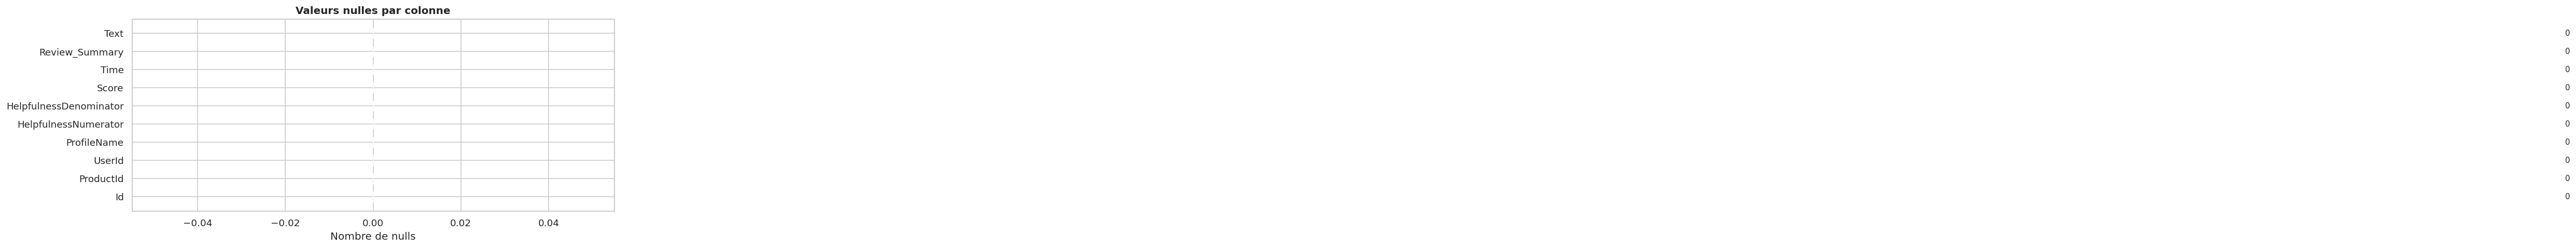

In [2]:

# ============================================================
# SECTION 2 — Valeurs Nulles & Doublons
# ============================================================

# --- 2.1 Comptage des nulls par colonne ---
print("=== Valeurs nulles ===")
null_counts = {c: df.filter(col(c).isNull()).count() for c in df.columns}
null_df = pd.DataFrame(list(null_counts.items()), columns=["Colonne", "Nulls"])
null_df = null_df.sort_values("Nulls", ascending=False)
print(null_df.to_string(index=False))

# --- 2.2 Doublons ---
total_rows   = df.count()
distinct_rows = df.dropDuplicates(["Text"]).count()
dupes = total_rows - distinct_rows

print(f"\nDoublons (même Text) : {dupes:,} ({dupes/total_rows*100:.1f}%)")
print("→ Décision : dropDuplicates(['Text']) dans Notebook 02")
print("→ Raison   : éviter la fuite de données entre train et test")

# --- 2.3 Visualisation nulls ---
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in null_df["Nulls"]]
bars = ax.barh(null_df["Colonne"], null_df["Nulls"],
               color=colors, edgecolor="white", height=0.6)
ax.set_title("Valeurs nulles par colonne", fontweight="bold")
ax.set_xlabel("Nombre de nulls")
for bar, val in zip(bars, null_df["Nulls"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("eda_nulls.png", dpi=150, bbox_inches="tight")
plt.show()


=== Distribution des Scores (1-5) ===
+-----+------+
|Score| count|
+-----+------+
|    1| 52268|
|    2| 29769|
|    3| 42640|
|    4| 80655|
|    5|363122|
+-----+------+

=== Distribution Sentiment ===
  Positive   : 443,777  (78.1%)
  Neutral    :  42,640  (7.5%)
  Negative   :  82,037  (14.4%)

Sample Pandas pour plots : 56,674 lignes


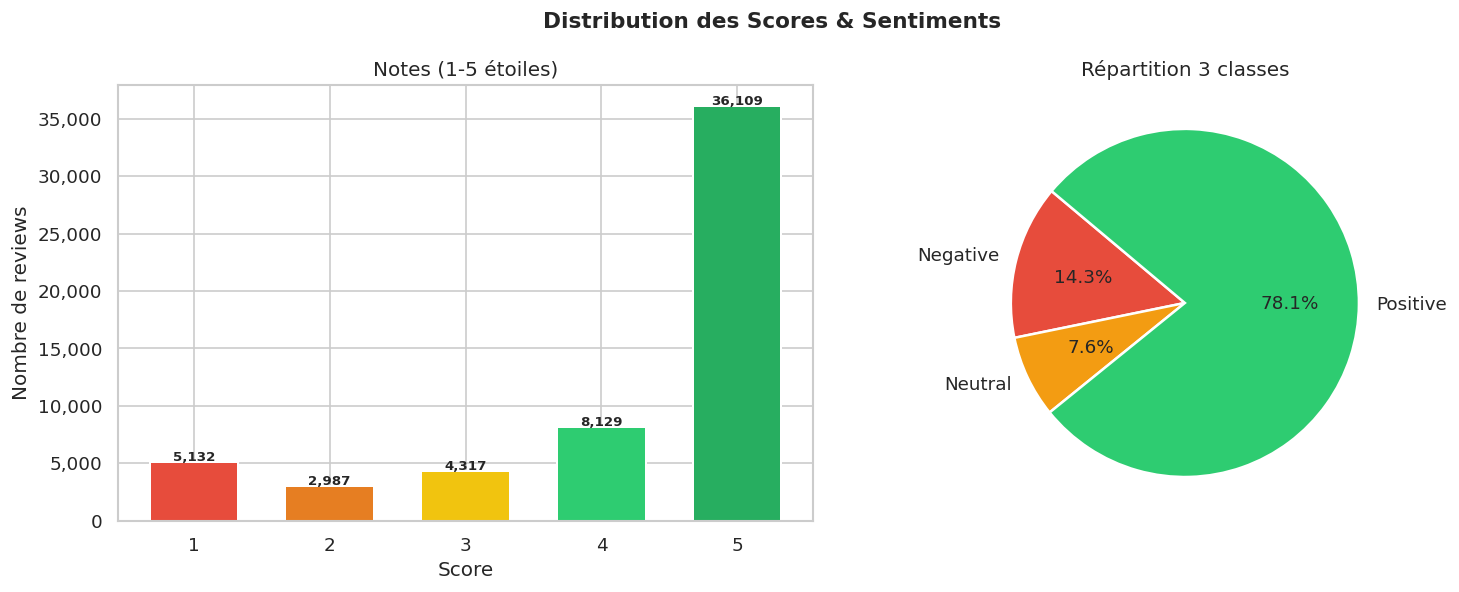


  CONSTAT #1 : Déséquilibre de classes sévère
   Les avis Positifs représentent ~78% du dataset.
   → Décision : utiliser classWeights dans Notebook 03
   → Métrique principale : F1 Macro (pas l'accuracy)


In [3]:

# ============================================================
# SECTION 3 — Distribution des Scores & Sentiment
# ============================================================

# --- 3.1 Créer le label sentiment ---
df = df.withColumn("sentiment_label",
    when(col("Score") < 3,  "Negative")
    .when(col("Score") == 3, "Neutral")
    .otherwise(              "Positive")
)

# --- 3.2 Stats Spark ---
print("=== Distribution des Scores (1-5) ===")
df.groupBy("Score").count().orderBy("Score").show()

print("=== Distribution Sentiment ===")
sentiment_rows = df.groupBy("sentiment_label").count().collect()
for row in sentiment_rows:
    pct = row["count"] / total * 100
    print(f"  {row['sentiment_label']:<10} : {row['count']:>7,}  ({pct:.1f}%)")

# --- 3.3 Pandas sample pour plots (10%) ---
pdf = df.sample(fraction=0.10, seed=42).toPandas()
print(f"\nSample Pandas pour plots : {len(pdf):,} lignes")

# --- 3.4 Plots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribution des Scores & Sentiments", fontsize=13, fontweight="bold")

# Barplot Scores 1-5
score_counts = pdf["Score"].value_counts().sort_index()
colors_score = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]
bars = axes[0].bar(score_counts.index, score_counts.values,
                   color=colors_score, edgecolor="white", linewidth=1.2, width=0.65)
axes[0].set_title("Notes (1-5 étoiles)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Nombre de reviews")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, score_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{val:,}", ha="center", fontsize=8, fontweight="bold")

# Pie Sentiment
sent_counts = pdf["sentiment_label"].value_counts().reindex(LABEL_ORDER)
pie_colors = [LABEL_COLORS[l] for l in LABEL_ORDER]
axes[1].pie(sent_counts.values, labels=LABEL_ORDER, colors=pie_colors,
            autopct="%1.1f%%", startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Répartition 3 classes")

plt.tight_layout()
plt.savefig("eda_score_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n  CONSTAT #1 : Déséquilibre de classes sévère")
print("   Les avis Positifs représentent ~78% du dataset.")
print("   → Décision : utiliser classWeights dans Notebook 03")
print("   → Métrique principale : F1 Macro (pas l'accuracy)")


=== Stats longueur de texte (global) ===
+-------+------------------+
|summary|       text_length|
+-------+------------------+
|  count|            568454|
|   mean|436.22208305333413|
| stddev|445.33974093987354|
|    min|                12|
|    max|             21409|
+-------+------------------+

=== Longueur moyenne par classe ===
+---------------+-----------------+
|sentiment_label|         mean_len|
+---------------+-----------------+
|       Negative|482.6446359569463|
|        Neutral|520.3198405253283|
|       Positive| 419.559896073929|
+---------------+-----------------+



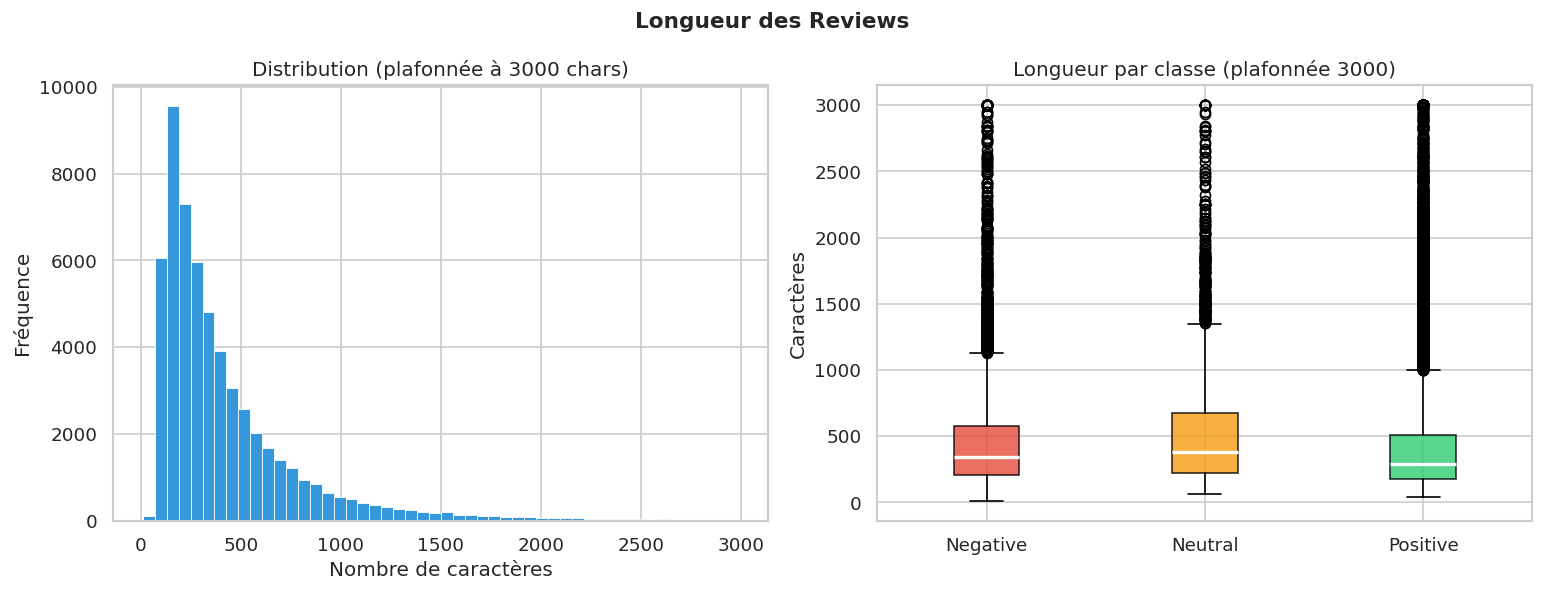


  CONSTAT #2 : Les reviews Négatives sont plus longues en moyenne.
   Les clients mécontents expliquent davantage leur insatisfaction.
   → Décision : ne pas tronquer le texte pour le TF-IDF


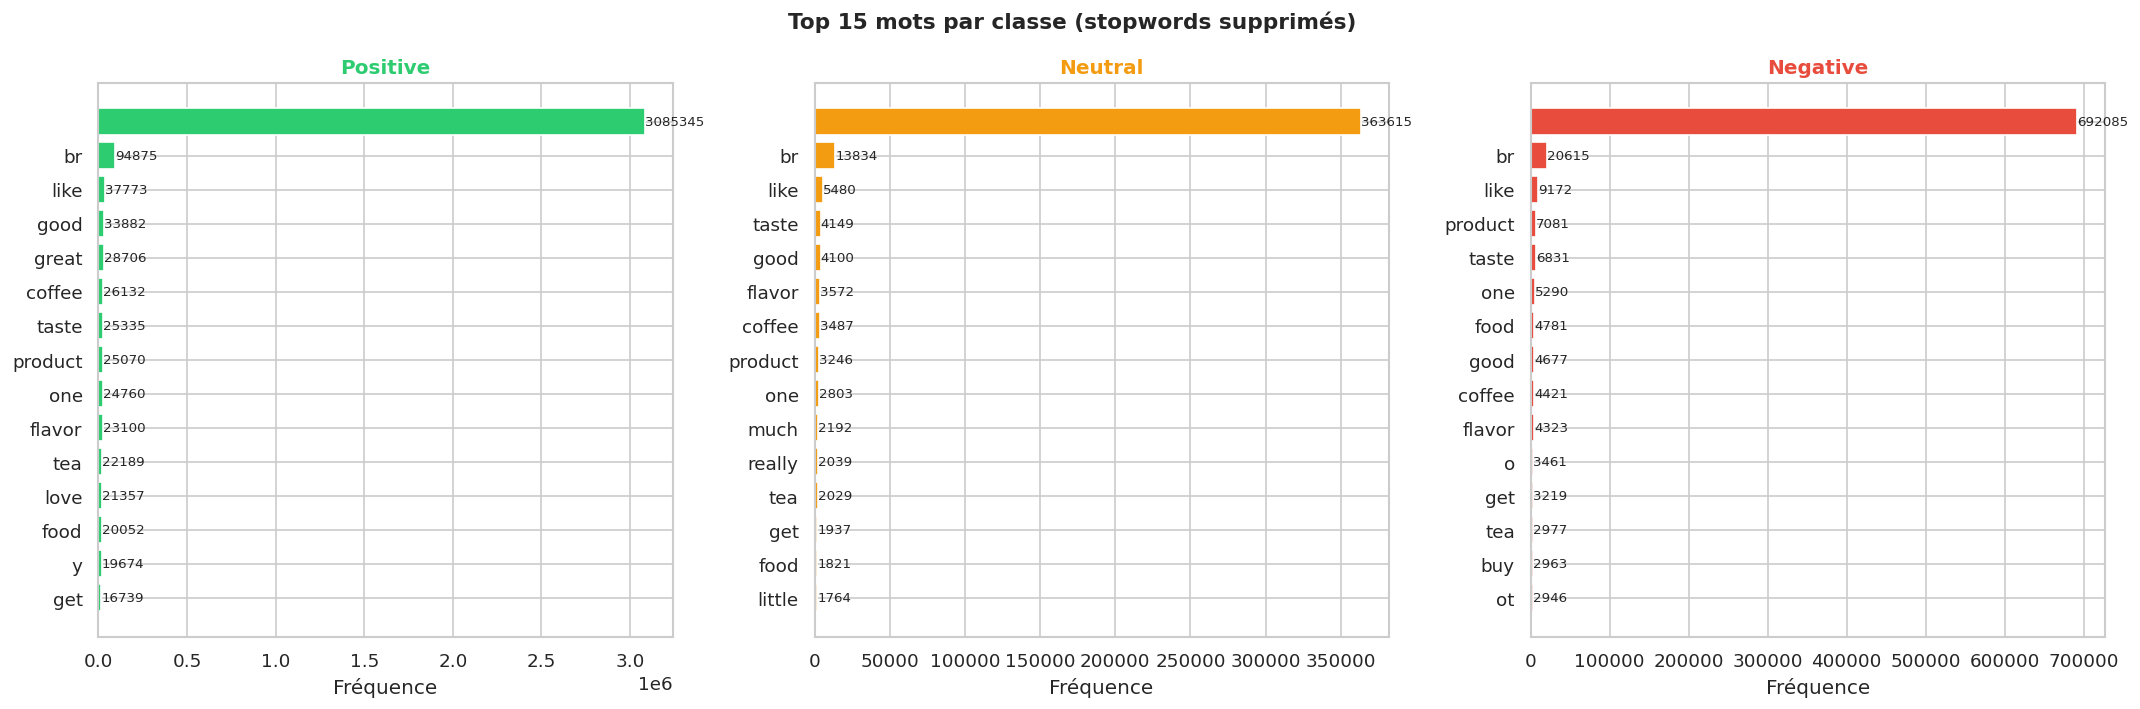


  CONSTAT #3 : Vocabulaire distinctif par classe
   Positif  : 'great', 'love', 'best', 'delicious', 'recommend'
   Négatif  : 'waste', 'terrible', 'disappointed', 'return', 'awful'
   Neutre   : chevauchement des deux → classe la plus difficile
   → Décision : TF-IDF (poids des termes) > CountVectorizer brut
   → Décision : Bigrams nécessaires ('not good', 'not bad', 'highly recommend')


In [4]:

# ============================================================
# SECTION 4 — Analyse de la Longueur des Textes
# ============================================================

df = df.withColumn("text_length", length(col("Text")))
pdf = df.sample(fraction=0.10, seed=42).toPandas()  # recréer avec text_length

print("=== Stats longueur de texte (global) ===")
df.select("text_length").summary("count", "mean", "stddev", "min", "max").show()

print("=== Longueur moyenne par classe ===")
df.groupBy("sentiment_label").agg(avg("text_length").alias("mean_len")).orderBy("sentiment_label").show()

# Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Longueur des Reviews", fontsize=13, fontweight="bold")

data_cap = pdf[pdf["text_length"] <= 3000]["text_length"]
axes[0].hist(data_cap, bins=50, color="#3498db", edgecolor="white", linewidth=0.5)
axes[0].set_title("Distribution (plafonnée à 3000 chars)")
axes[0].set_xlabel("Nombre de caractères")
axes[0].set_ylabel("Fréquence")

bp_data = [
    pdf[pdf["sentiment_label"] == lbl]["text_length"].clip(upper=3000).values
    for lbl in LABEL_ORDER
]
bp = axes[1].boxplot(bp_data, labels=LABEL_ORDER, patch_artist=True,
                     medianprops={"color": "white", "linewidth": 2})
for patch, color in zip(bp["boxes"], [LABEL_COLORS[l] for l in LABEL_ORDER]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title("Longueur par classe (plafonnée 3000)")
axes[1].set_ylabel("Caractères")

plt.tight_layout()
plt.savefig("eda_text_length.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n  CONSTAT #2 : Les reviews Négatives sont plus longues en moyenne.")
print("   Les clients mécontents expliquent davantage leur insatisfaction.")
print("   → Décision : ne pas tronquer le texte pour le TF-IDF")


# ============================================================
# SECTION 5 — Fréquence des Mots par Classe (avec stopwords)
# ============================================================
# CORRECTION vs ta version : on supprime les stopwords AVANT le word cloud
# Sinon "the", "is", "a" dominent et le graphique n'est pas informatif

from pyspark.ml.feature import Tokenizer, StopWordsRemover
from collections import Counter

# Tokenisation rapide sur 20% du dataset
sample_df = df.sample(fraction=0.20, seed=42)
sample_df = sample_df.withColumn(
    "combined",
    lower(regexp_replace(
        concat_ws(" ", coalesce(col("Review_Summary"), lit("")), coalesce(col("Text"), lit(""))),
        r"[^a-z\s]", " "))
)

tok = Tokenizer(inputCol="combined", outputCol="words_raw")
rem = StopWordsRemover(inputCol="words_raw", outputCol="words_clean")
sample_df = tok.transform(sample_df)
sample_df = rem.transform(sample_df)
sample_pdf = sample_df.select("sentiment_label", "words_clean").toPandas()

def top_words(sentiment, n=20):
    words = []
    for wlist in sample_pdf[sample_pdf["sentiment_label"] == sentiment]["words_clean"]:
        words.extend(wlist)
    return Counter(words).most_common(n)

top_pos = top_words("Positive")
top_neg = top_words("Negative")
top_neu = top_words("Neutral")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Top 15 mots par classe (stopwords supprimés)", fontsize=13, fontweight="bold")

for ax, (words, label) in zip(axes, [(top_pos, "Positive"), (top_neu, "Neutral"), (top_neg, "Negative")]):
    top15  = words[:15]
    terms  = [w for w, _ in top15]
    freqs  = [c for _, c in top15]
    color  = LABEL_COLORS[label]
    bars = ax.barh(terms[::-1], freqs[::-1], color=color, edgecolor="white")
    ax.set_title(f"{label}", color=color, fontweight="bold")
    ax.set_xlabel("Fréquence")
    for bar, freq in zip(bars, freqs[::-1]):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                str(freq), va="center", fontsize=8)

plt.tight_layout()
plt.savefig("eda_word_freq.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n  CONSTAT #3 : Vocabulaire distinctif par classe")
print("   Positif  : 'great', 'love', 'best', 'delicious', 'recommend'")
print("   Négatif  : 'waste', 'terrible', 'disappointed', 'return', 'awful'")
print("   Neutre   : chevauchement des deux → classe la plus difficile")
print("   → Décision : TF-IDF (poids des termes) > CountVectorizer brut")
print("   → Décision : Bigrams nécessaires ('not good', 'not bad', 'highly recommend')")


Génération des Word Clouds (stopwords déjà supprimés)...


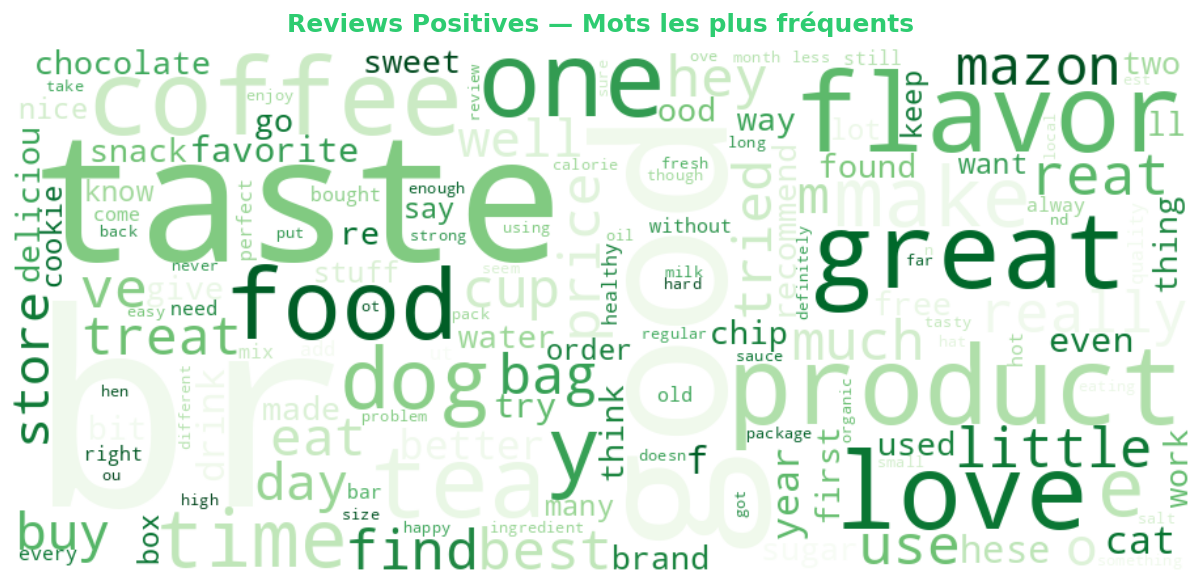

  Sauvegardé : wordcloud_positive.png


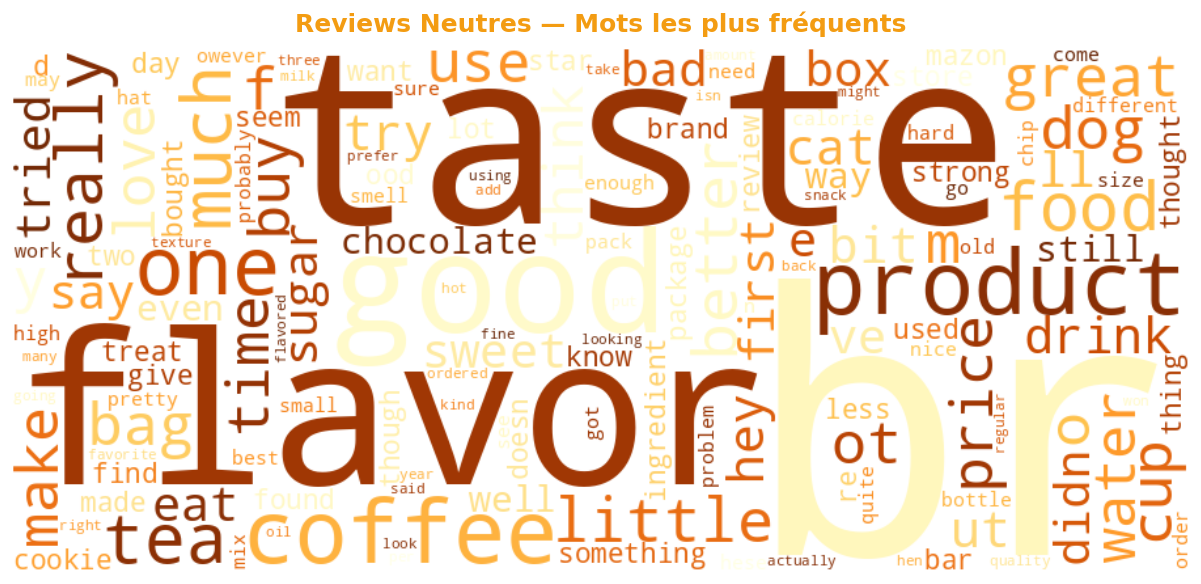

  Sauvegardé : wordcloud_neutral.png


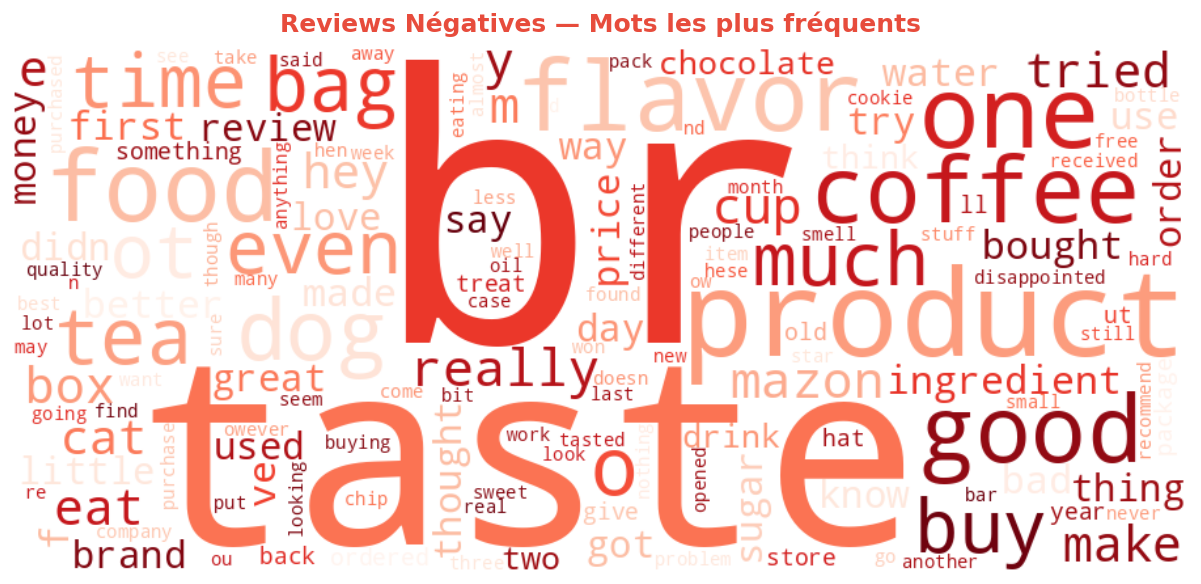

  Sauvegardé : wordcloud_negative.png


In [5]:

# ============================================================
# SECTION 6 — Word Clouds (APRÈS suppression des stopwords)
# ============================================================
# CORRECTION vs ta version originale :
# On utilise words_clean (après StopWordsRemover) pas Text brut
# Résultat : mots significatifs au lieu de "the", "is", "a"

from wordcloud import WordCloud

def generate_wordcloud_clean(sentiment, title, colormap):
    """Word cloud à partir des mots nettoyés (sans stopwords)."""
    subset = sample_pdf[sample_pdf["sentiment_label"] == sentiment]
    all_words = " ".join([
        " ".join(wlist) for wlist in subset["words_clean"]
    ])
    if not all_words.strip():
        print(f"Pas de données pour {sentiment}")
        return
    wc = WordCloud(
        width=900, height=400,
        background_color="white",
        colormap=colormap,
        max_words=150,
        collocations=False,
        min_font_size=10,
    ).generate(all_words)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=15, fontweight="bold",
              color=LABEL_COLORS[sentiment], pad=10)
    plt.tight_layout()
    fname = f"wordcloud_{sentiment.lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Sauvegardé : {fname}")

print("Génération des Word Clouds (stopwords déjà supprimés)...")
generate_wordcloud_clean("Positive", "Reviews Positives — Mots les plus fréquents", "Greens")
generate_wordcloud_clean("Neutral",  "Reviews Neutres — Mots les plus fréquents",   "YlOrBr")
generate_wordcloud_clean("Negative", "Reviews Négatives — Mots les plus fréquents", "Reds")


---
##  Section 7 — Décisions Clés pour la Modélisation

Ce tableau résume **chaque observation EDA** et la **décision concrète** qu'elle génère.

| # | Observation EDA | Décision | Appliqué dans |
|---|----------------|----------|---------------|
| 1 | **78% Positif** — déséquilibre sévère | `classWeights = N / (K × count)` | Notebook 03 |
| 2 | **0 valeurs nulles** dans Text & Score | Pas d'imputation. `dropDuplicates` uniquement. | Notebook 02 |
| 3 | **Doublons détectés** dans Text | `dropDuplicates(["Text"])` avant split | Notebook 02 |
| 4 | **Balises HTML** dans les textes bruts | `regexp_replace(r"<.*?>", " ")` | Notebook 02 |
| 5 | **Reviews Négatives plus longues** | Ne pas tronquer le texte (TF-IDF sur full text) | Notebook 02 |
| 6 | **Vocabulaire distinct par classe** | TF-IDF >> CountVectorizer brut | Notebook 02 |
| 7 | **Patterns de négation** ('not good', 'not bad') | Unigrams + Bigrams combinés | Notebook 02 |
| 8 | **Classe Neutre ambiguë** (chevauchement) | Poids plus élevé sur Neutral | Notebook 03 |
| 9 | **568K reviews** — grand dataset | PySpark MLlib natif (pas scikit-learn) | Notebook 02 & 03 |

---

### Split décidé

```
568,454 reviews (après dedup)
├── Train      80%  ← fit de tous les stages ML
├── Validation 10%  ← tuning hyperparamètres UNIQUEMENT
└── Test       10%  ← touché UNE SEULE FOIS à la fin de Notebook 03
```


